In [1]:
#from PIL import Image

In [2]:
import os
import torch
from IPython import get_ipython # type: ignore

def get_runtime_info():
    # 1) Détecter si on est sur Google Colab
    try:
        in_colab = 'google.colab' in str(get_ipython()) # type: ignore
    except NameError:
        in_colab = False

    # 2) Vérifier CUDA (GPU NVIDIA, typiquement sur Colab)
    cuda_available = torch.cuda.is_available()

    # 3) Vérifier MPS (GPU Apple Silicon, typiquement en local sur Mac)
    mps_available = getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available()

    if in_colab and cuda_available:
        device = torch.device("cuda")
        location = "colab_cuda"
    elif mps_available:
        device = torch.device("mps")
        location = "local_mps"
    else:
        device = torch.device("cpu")
        location = "cpu"

    return {
        "in_colab": in_colab,
        "cuda_available": cuda_available,
        "mps_available": mps_available,
        "device": device,
        "location": location,  # "colab_cuda", "local_mps" ou "cpu"
    }

info = get_runtime_info()
print("device",info["device"])
device=info["device"]

device mps


# __`Speech Command Recognition`__ 

__NOM ETUDIANT : Gérard BENITAH__

lauriane.bompay@irit.fr

__`Présentation de l'article`__.   
L’article présente un système de reconnaissance de commandes vocales, à faible latence et faible empreinte mémoire, basé sur différents modèles de réseaux de neurones (softmax simple, dnn et cnn) appliqués au Speech Commands Dataset de Google (65 000 fichiers WAV, 30 mots, 1 s chacun).
Les auteurs extraient des caractéristiques MFCC sur des fenêtres de 30 ms (stride 10 ms), produisant des matrices 2D 98×40 qui servent d’entrée aux réseaux.

__`Abstract`__
Projet visant à construire un système de reconnaissance de commandes vocales précis, léger et à faible latence, capable de détecter des mots-clés prédéfinis.
À partir du jeu de données Speech Commands de Google, différentes architectures sont testées : 
 - modèle softmax simple, 
 - réseau de neurones profond (dnn) et 
 - réseau de neurones convolutif (cnn).
Le cnn surpasse les deux autres modèles et atteint une exactitude de 95,1% sur 6 étiquettes.

__`Résumé de l’introduction`__.  
L’interaction vocale sur mobile (Google Now, Siri, “Ok Google”) repose sur la détection de mots-clés (keyword spotting, KWS), pratique pour les scénarios mains libres et les situations de conduite ou d’urgence.
Comme ces systèmes tournent sur smartphone ou tablette, ils doivent être rapides, peu gourmands en mémoire et en calcul, d’où la recherche d’architectures compactes.
Le système classifie chaque clip d’une seconde comme « silence », « mot inconnu » ou l’un des mots-clés prédéfinis (par ex. yes/no, up/down/left/right, stop/go), puis utilise les trois modèles (softmax, dnn, cnn) pour produire une probabilité et un label final.

__`Résumé de la partie modèles et résultats`__.   
 - `Vanilla softmax` : une couche entièrement connectée avec softmax, très rapide mais peu précise (environ 56% de précision test).
 - `dnn` : 3 couches cachées de 128 neurones avec ReLU et dropout, meilleure précision (≈72%) mais plus de paramètres et de calcul.
 - `cnn` : 2 couches de convolution, couches de pooling, dropout, couche linéaire basse dimension, puis fully-connected + softmax, (environ 94,5% de précision en test).

### `I Préparation des données`

In [3]:
#%pip install numpy scipy matplotlib tqdm 
#python -m pip install ipykernel
#%pip -q install scikit-learn

In [4]:
import torch, torchaudio
print(torch.__version__, torchaudio.__version__)

from torchaudio.datasets import SPEECHCOMMANDS

2.5.1 2.5.1


#### `1.1 Technologie de repérage de mots-clés (KWS)`

`Technologie de repérage de mots-clés (KWS) fournie une interface mains libres`
 - KEYWORDS = ["up", "down", "left", "right"]
 - SILENCE_LABEL = "_silence_"
 - UNKNOWN_LABEL = "_unknown_" #  the background volume is 0.1 and its frequency is 0.8.

#### `1.2 Rappels sur les splits Speech Commands`

In [5]:
import os
import random
import torch
from torch.utils.data import Dataset
import torch.nn.functional as F
import torchaudio
import numpy as np

root_dir = "M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/data/speech_commands/"
# ------------------------------------------------------------------
# Mapping label texte -> label compact
# À adapter à ton mapping exact
# ------------------------------------------------------------------
KLASSES = ["down", "left", "right", "up", "silence"]
CLASSES = ["down", "left", "right", "up", "_background_noise_"]
n_classes = len(KLASSES)

label2id = {c: i for i, c in enumerate(KLASSES)}
id2label = {v: k for k, v in label2id.items()}

def word_to_label(word_str: str) -> str:
    if word_str in KLASSES:
        return word_str
    elif word_str == "_background_noise_":
        return "silence"
    else:
        return "unknown"  # dans le où l'on garderait d'autres mots non compris dans les classes
    
validate_every=400
num_steps=40000
patience=50  

#### `1.3. Construction de liste filtrée par KEYWORDS`

In [6]:
import os

def load_list(path_txt):
    with open(path_txt) as f:
        return [line.strip() for line in f]

def filter_keywords(file_list, keywords): # right/bb05582b_nohash_3.wav
    out = []
    for rel_path in file_list:
        label = rel_path.split("/")[0]
        if label in keywords:
            out.append(rel_path)       
    return out

#### `1.4. Lister tous les fichiers des 4 mots + bruit`
 - Pour les 4 mots « normaux », utiliser les fichiers exactement comme down/xxx.wav, etc. 
 - Pour le bruit, tu ne prendras pas directement les gros WAV, les prendre tous pour plus tard pour extraire des segments de 1 s.

In [7]:
#def add_Noise2List(train_files, val_files, test_files):
def TrainList_and_add_Noise2Lists():
    for kw in CLASSES:
        class_dir = os.path.join(root_dir, kw)
        if not os.path.isdir(class_dir):
            continue
        for fname in os.listdir(class_dir):
            if not fname.endswith(".wav"):
                continue
            rel_path = f"{kw}/{fname}"
            if kw == "_background_noise_":
                train_files.extend([rel_path] * 100) 
                val_files.extend([rel_path] * 15)  
                test_files.extend([rel_path] * 15)   
            if (rel_path not in val_files) and (rel_path not in test_files):
                train_files.extend([rel_path])        
    return train_files, val_files, test_files

train_files = []  

val_files = filter_keywords(load_list(os.path.join(root_dir, "validation_list.txt")), CLASSES)
test_files = filter_keywords(load_list(os.path.join(root_dir, "testing_list.txt")), CLASSES)                 
train_files, val_files, test_files = TrainList_and_add_Noise2Lists()            

#### `1.5 Mode de représentation, features`

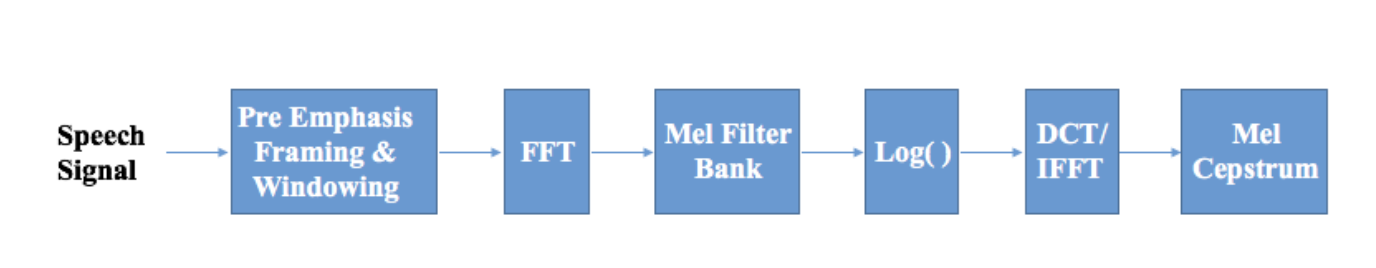

In [8]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/mfcc.png",width=700))

`Pipeline MFCC :`
 - Mel‑spectrogram interne (avec n_fft=512, n_mels=40, mêmes win/hop).
 - Passage au log (log‑énergie Mel).
 - DCT (transformée en cosinus) sur l’axe fréquence pour obtenir les coefficients cepstraux.
 - On ne garde que les premiers coefficients n_mfcc (e.g. 40).
 - On utilise torchaudio.transforms.MFCC, qui encapsule : 
 - pré‑accentuation → fenêtrage → FFT → banc de filtres Mel → log → DCT → Mel Cepstrum / MFCC, 

`Conséquence :`
 - MelSpectrogram → features de forme (time, n_mels) avec beaucoup de détails spectraux.
 - MFCC → features de forme (time, n_mfcc) plus compacts et décorrelés, 
 - typiquement mieux adaptés à des modèles « classiques » (GMM‑HMM, MLP, RNN légers) et souvent utilisés en reconnaissance de parole.

`Mode de répsentation :`
 - le train_transform = AT.MelSpectrogram(...), pour un pipeline spectrogrammes (par ex. cnn 2D sur Mel‑spectrogrammes).
 - la classe WavMFCCDataset est, conçue pour un pipeline MFCC (feature vector 98×40).

`Choix de la famille de features :`

 - __Si le modèle attend des MFCC 2D (98×40):__  
   - on utilise WavMFCCDataset avec self.mfcc_transform et pas les MelSpectrogram externes.
   - Si au contraire on veut travailler en Mel‑spectrogrammes purs, 
   - il faut abandonner MFCC et passer directement par MelSpectrogram (+ éventuellement AmplitudeToDB).

__`Conclusion`__ : 
 - Ces deux blocs représentent deux choix de représentation. 
 - Pour ce TP, au vu de la classe, le plus cohérent est de cnoserver les MFCC 

#### `1.6 Chargement des WAV et extraction MFCC`

 - parcourt une arborescence de WAV (type Speech Commands) ;
 - convertit chaque fichier en MFCC fixes 98×40 ;
 - remappe les dossiers/mots en labels compacts.

`_load_waveform`. 
- Charge le waveform avec torchaudio.load(path) → tenseur (1, T) et fréquence sr.
- Si sr diffère de self.sample_rate, il resample l’audio vers self.sample_rate.
- Gère le bruit de fond :

  - Définit num_samples = sample_rate (durée cible = 1 s).
  - Si l’audio est plus long que 1 s :
  - Tire un start aléatoire, découpe un segment de longueur num_samples.
  - Si l’audio est plus court que 1 s :
  - Ajoute du padding en fin pour atteindre exactement 1 s.
  - Retourne le waveform (1, T') ainsi traité.

`getitem`. 
 - Récupère wav_path, label_str = self.files[idx].
 - Charge l’audio par waveform = self._load_waveform(wav_path, label_str) → (1, T).
 - Calcul des MFCC :
   - Ajuste de la durée en frames à target_T :
   - Si T_frames < target_T : pad à droite pour obtenir target_T.
   - Sinon : tronque à mfcc[:, :target_T].
 - Mapping du label texte vers un entier et normalise le label.
 - Mise en forme finale des features passe de (n_mfcc, T) à (T, n_mfcc) 
 - Retourne mfcc : tenseur (T, n_mfcc) normalisé/padé/tronquéet un label_id : entier correspondant à la classe.

In [9]:
# ------------------------------------------------------------------
# Dataset MFCC à partir d'une liste de chemins relatifs
#   - gère les mots "normaux" et le bruit de fond
#   - pour le bruit: extrait des segments aléatoires de 1 s
# ------------------------------------------------------------------
class WavMFCCDataset(Dataset):
    def __init__(
        self,
        root_dir,
        file_list,          # liste de chemins relatifs: label/xxx.wav (incluant _background_noise_)
        sample_rate=16000,
        n_mfcc=40,
        win_length_ms=30,
        hop_length_ms=10,
        target_T=98,        # nombre de frames temporelles (≈ 1 s avec 30 ms / 10 ms)
        one_sec_noise=True  # si True: pour _background_noise_, on prend un segment de 1 s
    ):
        """
        root_dir  : racine du dataset Speech Commands
        file_list : liste de chemins relatifs (label/filename.wav) pour ce split (train/val/test)
        """
        self.root_dir = root_dir
        self.sample_rate = sample_rate
        self.target_T = target_T
        self.one_sec_noise = one_sec_noise

        # Construire (chemin absolu, label_str)
        self.files = []
        for rel_path in file_list:
            label_str = rel_path.split("/")[0]
            full_path = os.path.join(root_dir, rel_path)
            self.files.append((full_path, label_str))

        # Paramètres MFCC en nombre d'échantillons
        win_length = int(sample_rate * win_length_ms / 1000)
        hop_length = int(sample_rate * hop_length_ms / 1000)

        self.mfcc_transform = torchaudio.transforms.MFCC(
            sample_rate=sample_rate,
            n_mfcc=n_mfcc,
            melkwargs={
                "win_length": win_length,
                "hop_length": hop_length,
                "center": True,
                "f_min": 20.0,
                "n_mels": 40,
                "n_fft": 512,
                "f_max": 8000.0,
            },
        )

    def __len__(self):
        return len(self.files)

    def _load_waveform(self, path, label_str):
        waveform, sr = torchaudio.load(path)  # (1, T)
        if sr != self.sample_rate:
            waveform = torchaudio.functional.resample(waveform, sr, self.sample_rate)

        # Cas spécial: bruit de fond -> échantillon 1 s aléatoire si demandé
        if self.one_sec_noise and label_str == "_background_noise_":
            num_samples = self.sample_rate  # 1 s
            total = waveform.size(1)
            if total > num_samples:
                start = random.randint(0, total - num_samples)
                waveform = waveform[:, start:start + num_samples]
            elif total < num_samples:
                # pad si < 1 s
                pad = num_samples - total
                waveform = F.pad(waveform, (0, pad))

        return waveform

    def __getitem__(self, idx):
        wav_path, label_str = self.files[idx]

        waveform = self._load_waveform(wav_path, label_str)  # (1, T)

        # MFCC: (1, n_mfcc, T_frames)
        mfcc = self.mfcc_transform(waveform)
        mfcc = mfcc.squeeze(0)  # (n_mfcc, T_frames)

        # Padding / troncature en temps à target_T
        T = mfcc.shape[1]
        if T < self.target_T:
            pad = self.target_T - T
            mfcc = F.pad(mfcc, (0, pad))
        else:
            mfcc = mfcc[:, :self.target_T]

        # mapping label texte -> label compact
        mapped = word_to_label(label_str)
        label_id = label2id[mapped]  # entier 0..len(CLASSES)-1

        # Retour (T, n_mfcc) = (98, 40) pour un réseau type cnn/RNN
        mfcc = mfcc.transpose(0, 1)  # (T, n_mfcc)

        return mfcc, label_id


#### `1.7. Définition des datasets`

In [10]:
from torch.utils.data import DataLoader

# Datasets "bruit"
# TODO: fixer des tailles équilibrées
train_dataset = WavMFCCDataset(root_dir, train_files, one_sec_noise=True)
val_dataset   = WavMFCCDataset(root_dir, val_files,   one_sec_noise=True)
test_dataset  = WavMFCCDataset(root_dir, test_files,  one_sec_noise=True)

#### `1.8. Définition des DataLoader`

In [11]:
# DataLoader 
train_loader = DataLoader(train_dataset, batch_size=64, num_workers=0, pin_memory=False, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, num_workers=0, pin_memory=False, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, num_workers=0, pin_memory=False, shuffle=False)

In [12]:
print(f"len train_loader : {train_loader.batch_size}, echantillon : {len(train_loader.dataset)}") #type: ignore
print(f"len val_loader : {val_loader.batch_size}, echantillon : {len(val_loader.dataset)}") #type: ignore
print(f"len test_loader : {test_loader.batch_size}, echantillon : {len(test_loader.dataset)}") #type: ignore

len train_loader : 64, echantillon : 12738
len val_loader : 64, echantillon : 1532
len test_loader : 64, echantillon : 1729


#### `1.9 Définition du contenu des dataset`

In [13]:
countstrain = {k: 0 for k in KLASSES}
countsvalid = {k: 0 for k in KLASSES}
countstest = {k: 0 for k in KLASSES}

for p in train_files:
    countstrain[word_to_label(p.split('/')[0])] += 1

for p in val_files:
    countsvalid[word_to_label(p.split('/')[0])] += 1

for p in test_files:
    countstest[word_to_label(p.split('/')[0])] += 1

print("count train class items:", countstrain)
print("count valid  class items:", countsvalid)
print("count test  class items :", countstest)
    
print(f"\ncount train items : {sum(countstrain.values())}")
print(f"count valid items : {sum(countsvalid.values())}") 
print(f"count test items  : {sum(countstest.values())}")


count train class items: {'down': 3134, 'left': 3037, 'right': 3019, 'up': 2948, 'silence': 600}
count valid  class items: {'down': 377, 'left': 352, 'right': 363, 'up': 350, 'silence': 90}
count test  class items : {'down': 406, 'left': 412, 'right': 396, 'up': 425, 'silence': 90}

count train items : 12738
count valid items : 1532
count test items  : 1729


### `2. Choix des composants`  
#### `2.1 Optimizer`

| Optimizer           | Idée clé                                         | Avantages principaux                                           | Limites / risques                                   | Quand l’utiliser (pratique)                                                                      |
|---------------------|--------------------------------------------------|----------------------------------------------------------------|-----------------------------------------------------|---------------------------------------------------------------------------------------------------|
| SGD (pur)           | Pas fixe dans la direction du gradient moyen     | Simple, très léger en mémoire, bonne généralisation possible   | Convergence lente, sensible au LR et au bruit       | Rarement seul; plutôt à des fins pédagogiques ou avec très bon tuning sur petits modèles.        |
| SGD + momentum      | Ajoute une “inertie” (moyenne des gradients)     | Convergence plus rapide et stable que SGD pur, très bon en vision | Nécessite tuning fin (lr, momentum), pas adaptatif  | Grand classique pour CNN (ResNet, etc.) quand on vise la **meilleure généralisation**.  |
| RMSprop             | LR adaptatif par paramètre (moyenne grad²)      | Gère bien gradients bruyants / non stationnaires, bon pour RNN | Peut sur‑adapter, généralisation parfois inférieure | RNN, séquences ou environnements très bruités; moins courant pour vision/classif standard. |
| Adam                | RMSprop + momentum (1er et 2ᵉ moments)          | Converge vite, peu de tuning, robuste aux gradients bruités    | Peut moins bien généraliser, surfit plus facilement | **Très bon défaut** pour prototyper MLP/CNN/RNN, hyper pratique pour le projet audio. |
| AdamW               | Variante Adam avec weight_decay décorrélé       | Meilleure régularisation que Adam, très bon compromis speed/gen | Un peu plus de paramètres à tuner (lr, wd)         | Recommandé par défaut aujourd’hui pour beaucoup de tâches (vision, NLP, audio). |
| Adagrad             | LR qui décroît par paramètre (cumul grad²)      | Excellent sur features rares / données très creuses            | LR chute trop, stoppe l’apprentissage à long terme  | Cas très spécifiques de données très creuses (NLP sparse); peu utile pour ton cas audio. |
| Adadelta / Adamax   | Variantes adaptatives d’Adagrad/Adam            | Stables, peu de tuning, bonne robustesse                       | Souvent pas meilleurs qu’Adam/AdamW en pratique     | À tester si Adam/AdamW instables, mais rarement nécessaires comme premier choix.|
| Nadam               | Adam + Nesterov momentum                        | Convergence parfois un peu plus rapide qu’Adam                 | Tuning plus délicat, gains pas toujours significatifs | Option “plus exotique” si tu veux gratter un peu sur certaines tâches séquentielles.  |

#### `2.2 Loss`

| Type de problème                  | Loss courante                         | Avantages principaux                                                                 | Limites / remarques                                                         | Quand l’utiliser en pratique                                                                 |
|-----------------------------------|----------------------------------------|--------------------------------------------------------------------------------------|-------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------|
| Classification multi‑classe (1 label parmi 6) | CrossEntropyLoss (PyTorch)            | Standard de facto, gradients bien comportés, converge vite, gère directement les logits + softmax.[web:209][web:216] | Suppose un seul label correct par exemple, sensible au bruit de labels.     | Ton cas actuel (commandes audio exclusives up/down/…): **c’est le bon choix par défaut**.     |
| Classification binaire ou multi‑label (plusieurs labels vrais) | BCEWithLogitsLoss                     | Adapté quand chaque classe est indépendante (0/1), compatible avec sorties sigmoïdes indépendantes.[web:211][web:219] | Pas adapté si les classes s’excluent mutuellement (comme tes 6 commandes).  | Audio multi‑label (sons qui se chevauchent) ou détection d’événements simultanés.             |
| Classification avec fort déséquilibre | Focal Loss (basée sur cross‑entropy)  | Réduit le poids des exemples faciles, concentre l’apprentissage sur les classes rares/difficiles.[web:213][web:216][web:223] | Hyperparams à régler (γ, α), un peu plus instable si mal tunée.             | Si une ou deux classes audio sont très rares et mal apprises avec la cross‑entropy simple.    |
| Classification avec labels bruités / overfitting fort | Cross‑entropy + label smoothing       | Rend les cibles moins “dures”, améliore la généralisation et la calibration des probabilités.[web:213][web:216] | Peut légèrement dégrader la perf au top‑1 si labels propres.                 | Si tu observes sur‑apprentissage ou labels bruités dans tes annotations audio.                |
| Régression (valeur continue)      | MSELoss (L2)                           | Simple, bien adaptée quand la sortie est une valeur réelle (SNR, énergie…).[web:211][web:219] | Mauvais choix pour classification: convergence lente, gradients saturent.[web:210][web:214][web:220] | Pas pour tes 6 classes; à réserver à des sorties continues (scores, régressions audio).      |
| Régression robuste                | L1Loss (MAE)                           | Moins sensible aux outliers que MSE, utile pour certaines tâches de régression audio.[web:212][web:221] | Gradients constants, peut converger plus lentement.                           | Reconstruction de spectrogrammes/paramètres continus quand fortes valeurs aberrantes.         |
| Tâches complexes audio (TTS, séparation, etc.) | Combinaisons de pertes (L1/L2 spectrale, CE, perceptuelle, distillation…) | Permet de capturer plusieurs critères (fidélité spectrale, intelligibilité, etc.).[web:221] | Design plus complexe, tuning des pondérations nécessaire.                    | Pour des modèles audio avancés (TTS, enhancement), pas nécessaire dans notre setup actuel.      |

### `3 Modèle Vanilla Single Layer Softmax`

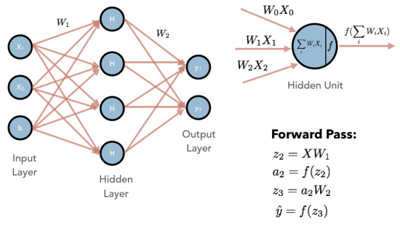

In [14]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/vanillaSoftMax.png", width=500,))

#### `3.1 Architecture`

 __Entrée attendue__ : 
  - un tenseur MFCC de taille 98×40 par exemple (temps × coefficients), 
  - éventuellement avec un canal supplémentaire (shape (B, 1, 98, 40) ou (B, 98, 40)).
 - Le modèle supprime le canal s’il existe 
 - Il platit en un vecteur de taille 3920, pour chaque exemple du batch.
 - Une unique couche linéaire nn.Linear(3920, n_classes) produit les logits de sortie, sans non‑linéarité intermédiaire, 
 - La CrossEntropyLoss applique le softmax.

__`Points forts`__
 - Très rapide à entraîner et à exécuter, nombre de paramètres limité.
 - Sert de baseline simple pour mesurer le gain apporté par des architectures plus sophistiquées (CNN/CRNN/transformers).
 - Implémentation facile à déboguer, pas de complexité sur les dimensions.

__`Limites`__
 - Ignorance quasi totale de la structure temporelle de la parole : tous les cadres sont juste concaténés dans un grand vecteur.
 - Ne modélise pas les patterns locaux temps‑fréquence (pas de convolutions, pas de contexte local explicite).
 - Risque de moins bien généraliser que des architectures exploitant la structure des spectrogrammes (CNN 2D, RNN, attention).

__`Quand l’utiliser`__
 - Comme modèle de départ pour un projet de classification de parole : établir une référence simple.
 - Pour vérifier pipeline de données, étiquettes, MFCC, etc., avant de passer à des modèles plus complexes. 

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VanillaSoftmaxSpeech(nn.Module):
    def __init__(self, n_frames=98, n_mfcc=40, n_classes=n_classes):
        super().__init__()
        self.in_features = n_frames * n_mfcc  # 98 * 40 = 3920
        self.fc = nn.Linear(self.in_features, n_classes)

    def forward(self, x):               # x peut être (batch, 1, 98, 40) ou (batch, 98, 40)
        if x.dim() == 4:                # (B, C, T, F) -> (B, T, F) si C=1
            x = x.squeeze(1)            # Aplatissement en vecteur
        x = x.reshape(x.size(0), -1)    # (B, 3920)
        logits = self.fc(x)             # (B, 30)
        return logits                   # CrossEntropyLoss fera softmax

### `3.1 Instanciation du modèle`

`Lien avec la CrossEntropy`
La loss par exemple vaut : 
- $\small log(p_{true})$, où $p_{true}$ est la sortie softmax associée au label correct
- si $p_{true}$ est proche de 1, la loss est proche de 0
- si $p_{true}$ est très petite (quasi 0), la loss devient très grande

__Interprétation dans tes logs__.   
 - Lorsque la loss est importante pour un seul exemple, $p_{true}$ est quasiment nul pour ce point, 
   - cela signifie que le modèle est très sûr de la mauvaise classe.
 - Lorsque tous les batchs ont une loss 0, 
   - cela correspond au cas (numérique) où $p_{true}$≈1 partout, donc CrossEntropy ≈ 0. 

In [16]:
from torch.optim.lr_scheduler import LambdaLR

model_van = VanillaSoftmaxSpeech(n_frames=98, n_mfcc=40, n_classes=n_classes).to(device)
criterion = nn.CrossEntropyLoss()

n_params = sum(p.numel() for p in model_van.parameters())
print("Nb de paramètres :", n_params)

#optimizer = torch.optim.SGD( model_van.parameters(),lr=0.001, momentum=0.5, nesterov=True)
optimizer_van = torch.optim.AdamW(model_van.parameters(),lr=1e-3,weight_decay=1e-4)
optimizer = optimizer_van

Nb de paramètres : 19605


In [17]:
num_epochs = 5
boundary = int(5 * num_epochs / 6)  # 5/6 du total

def lr_lambda(epoch):
    # epoch 0-4 : facteur 1.0 ; epoch >= 5 : facteur 0.1
    return 1.0 if epoch < boundary else 0.1

scheduler = LambdaLR(optimizer, lr_lambda=lr_lambda)

#### `3.2 Evaluation modèle`

In [18]:
from sklearn.metrics import accuracy_score
import numpy as np

def eval_model(model, data_loader,model_type="mlp", criterion=None):
    model.eval()
    running_loss = 0.0
    y_true = []
    y_pred = []
    y_proba = []  # score/proba pour ROC/PR (binaire ou pour une classe donnée)

    with torch.no_grad():
        for mfcc, labels in data_loader:
            mfcc = mfcc.to(device)

            if model_type == "cnn":
                mfcc = mfcc.unsqueeze(1)         # [B, 1, 98, 40]
            elif model_type == "mlp":
                mfcc = mfcc.view(mfcc.size(0), -1)
            elif model_type == "rnn":
                mfcc = mfcc                      # ou permute selon ton RNN

            labels = labels.to(device)
            logits = model(mfcc)              # (B, n_classes)
            if criterion is not None:
                val_loss = criterion(logits, labels)
                running_loss += val_loss.detach().cpu().numpy() * labels.size(0)

            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            y_true.extend(labels.cpu().numpy().tolist())
            y_pred.extend(preds.cpu().numpy().tolist())
            y_proba.append(probs.cpu().numpy())

    val_acc = accuracy_score(y_true, y_pred)
    all_proba = np.concatenate(y_proba, axis=0)  # (N, n_classes)

    if criterion is not None:
        loss = running_loss / len(y_true)
        return val_loss.item(), val_acc, y_true, y_pred, all_proba 
    else:
        return val_loss.item(), val_acc, y_true, y_pred, all_proba

#### `3.3 Training modèle`
`En résumé, le critère d’arrêt n’est pas la loss, mais l’AUC de validation.`

`Early stopping sur l’AUC`
 - On surveille l’AUC sur le jeu de validation à chaque epoch (ou à certains intervalles).
 - Tant que l’AUC de validation s’améliore, on continue l’entraînement.
 - Dès que l’AUC ne s’améliore plus pendant un certain nombre d’epochs consécutifs (patience), 
 - on arrête l’entraînement pour éviter le surapprentissage et de gaspiller du temps de calcul.

`Checkpoint sur l’AUC`
 - À chaque epoch, si l’AUC de validation est meilleure que la meilleure vue jusque‑là, on sauvegarde (poids) le modèle (checkpoint)
 - À la fin de l’entraînement (ou quand l’early stopping se déclenche), on recharge le meilleur checkpoint, 
 - c’est‑à‑dire le modèle qui avait l’AUC de validation maximale, et c’est celui‑là qu’on évalue sur le test set.


In [19]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.preprocessing import label_binarize
import numpy as np
import torch


def train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    criterion,
    num_steps=3300,
    validate_every=40,
    patience=10,
    checkpoint_path="best_model.pt",
    model_type="mlp"
):
    global_step = 0
    epoch = 0

    train_losses = []
    train_accuracy = []

    val_losses = []
    val_accs = []
    val_precs = []
    val_recalls = []
    val_aucs = []
    val_pr_aucs = []
    val_fprs = []        # dicts: classe -> fpr
    val_tprs = []        # dicts: classe -> tpr
    val_pr_precs = []    # dicts: classe -> precision
    val_pr_recalls = []  # dicts: classe -> recall

    # ---- early stopping / best checkpoint ----
    best_auc = -np.inf
    since_best = 0

    while global_step < num_steps:
        epoch += 1
        running_loss = 0.0
        correct = 0
        total = 0

        for i, (mfcc, labels) in enumerate(train_loader):
            model.train()
            mfcc = mfcc.to(device)
            labels = labels.to(device)
            
            if model_type == "cnn":
                x = mfcc.unsqueeze(1)          # [B, 1, 98, 40]
            elif model_type == "mlp":
                x = mfcc.view(mfcc.size(0), -1)  # [B, 98*40]
            elif model_type == "rnn":
                x = mfcc   

            if global_step >= num_steps:
                break

            logits = model(x)
            loss = criterion(logits, labels)

            proba = torch.softmax(logits, dim=1)
            num_classes = proba.shape[1]  # par ex. 6
            all_classes = np.arange(num_classes)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            global_step += 1

            batch_size = mfcc.size(0)
            running_loss += loss.item() * batch_size
            total += batch_size

            preds = logits.argmax(dim=1)
            correct += (preds == labels).sum().item()

            # ---------- validation ----------
            if global_step % validate_every == 0:
                val_loss, val_acc, y_true, y_pred, y_proba = eval_model(model, val_loader,model_type,criterion) 

                # métriques de base
                prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
                rec = recall_score(y_true, y_pred, average="macro", zero_division=0)

                y_true_arr = np.array(y_true)
                y_proba_arr = np.array(y_proba)

                classes_present = np.unique(y_true_arr)
                y_proba_sub_norm = y_proba_arr[:, classes_present]
                y_true_bin = label_binarize(y_true_arr, classes=classes_present)

                # AUC ROC macro one-vs-rest sur toutes les classes
                auc_scores = []
                for i_cls, c in enumerate(all_classes):
                    y_true_c = (y_true_arr == c).astype(int)
                    y_score_c = y_proba_arr[:, i_cls]
                    if y_true_c.min() == 0 and y_true_c.max() == 1:
                        auc_c = roc_auc_score(y_true_c, y_score_c)
                        auc_scores.append(auc_c)

                auc_roc = np.mean(auc_scores) if len(auc_scores) > 0 else np.nan

                # AP macro multi-classe (sur les classes présentes)
                ap = average_precision_score(
                    y_true_arr,
                    y_proba_sub_norm,
                    average="macro",
                )

                # binarisation pour les courbes par classe
                y_true_bin = label_binarize(
                    y_true_arr,
                    classes=classes_present,
                )

                fprs = {}
                tprs = {}
                pr_precs = {}
                pr_recalls = {}

                for i_cls, c in enumerate(classes_present):
                    y_true_c = y_true_bin[:, i_cls]
                    y_score_c = y_proba_sub_norm[:, i_cls]

                    fpr_c, tpr_c, _ = roc_curve(y_true_c, y_score_c)
                    prec_c, rec_c, _ = precision_recall_curve(y_true_c, y_score_c)

                    fprs[c] = fpr_c
                    tprs[c] = tpr_c
                    pr_precs[c] = prec_c
                    pr_recalls[c] = rec_c

                # stockage
                val_losses.append(val_loss)
                val_accs.append(val_acc)
                val_precs.append(prec)
                val_recalls.append(rec)
                val_aucs.append(auc_roc)
                val_pr_aucs.append(ap)

                val_fprs.append(fprs)
                val_tprs.append(tprs)
                val_pr_precs.append(pr_precs)
                val_pr_recalls.append(pr_recalls)

                print(
                    f"[step {global_step}] "
                    f"val loss = {val_loss:.4f}, "
                    f"acc = {val_acc*100:.2f}%, "
                    f"prec = {prec*100:.2f}%, "
                    f"rec = {rec*100:.2f}%, "
                    f"AUC = {auc_roc:.3f}, "
                    f"AP = {ap:.3f}"
                )
                
                # ----- early stopping + checkpoint sur AUC -----
                if not np.isnan(auc_roc) and auc_roc > best_auc:
                    best_auc = auc_roc
                    since_best = 0
                    print(
                        f"New best AUC = {best_auc:.3f} at step {global_step}, "
                        f"saving checkpoint to {checkpoint_path}"
                    )
                    torch.save(model.state_dict(), checkpoint_path)
                else:
                    since_best += 1
                    if since_best >= patience:
                        print(
                            f"Early stopping triggered after no AUC improvement "
                            f"for {since_best} validations (best AUC = {best_auc:.3f})"
                        )
                        # retour anticipé : on sort proprement de la fonction
                        return (
                            train_losses,
                            train_accuracy,
                            val_losses,
                            val_accs,
                            val_precs,
                            val_recalls,
                            val_aucs,
                            val_pr_aucs,
                            val_fprs,
                            val_tprs,
                            val_pr_precs,
                            val_pr_recalls,
                        )
                        
        # ---------- fin d’epoch ----------
        if total > 0:
            train_loss = running_loss / total
            train_acc = correct / total
            train_losses.append(train_loss)
            train_accuracy.append(train_acc)
            print(
                f"Epoch {epoch}: train loss = {train_loss:.4f} "
                f"train acc = {train_acc*100:.2f}%"
            )

        if scheduler is not None:
            scheduler.step()

    # fin normale (sans early stopping)
    return (
        train_losses,
        train_accuracy,
        val_losses,
        val_accs,
        val_precs,
        val_recalls,
        val_aucs,
        val_pr_aucs,
        val_fprs,
        val_tprs,
        val_pr_precs,
        val_pr_recalls,
    )

### `3.4 Métrics utilisées`

`Pendant l’entraînement`
 - __train_loss__ : ùoyenne de la loss sur les batches train de l’epoch courante, est une mesure de l’objectif du modèle.
 - __train_accuracy__: $roportion de prédictions correctes sur le train, preds = logits.argmax(dim=1) puis correct / total.
 
`À chaque validation on récupère : val_loss, val_acc, y_true, y_pred, y_proba`.
 - __val_loss__: loss moyenne sur le set de validation, permet de voir si il y a surapprentissage.
 - __val_acc__: accuracy sur la validation (même définition que train_accuracy).
 - __prec__ : precision_score(..., average="macro")
 - __Macro‑précision__ : précision par classe, puis moyenne sur les classes, recall_score(..., average="macro"), $precision_c = \frac{TP_c}{TP_c + FP_c}$ 
 - __Macro‑rappel__ : rappel par classe puis moyenne simple, $recall_c = \frac{TP_c}{TP_c + FN_c}$, sensible aux classes rares.

`AUC ROC multi‑classe`
 - pour chaque classe, on regarde la courbe ROC (TPR vs FPR) quand le seuil sur la proba de cette classe varie.
 - on prend l’aire sous la courbe (AUC) pour chaque classe, puis la moyenne sur les classes (average="macro").
 - cette métrique (auc_roc) sert à l’early stopping et au checkpoint pour la sauvegarde du meilleur modèle.

`Courbes par classe (ROC et PR)`
   - __val_fprs / val_tprs__ : liste de dictionnaires classe → vecteur fpr / tpr pour tracer les courbes ROC / classe.
   - __val_pr_precs / val_pr_recalls__ : idem pour les courbes précision‑rappel par classe. 


`Avec notre problème audio à 5 classes, on peut voir les métriques comme une “boîte à outils” où chaque outil répond à une question différente.  Métriques et usages recommandés (5 classes audio)`


| Métrique (dans le code)              | Ce que ça mesure                                                                 | Quand s’y fier                                                         | Sensible au déséquilibre ?                          | Usage pratique (6 classes audio)                                                                 |
|--------------------------------------|----------------------------------------------------------------------------------|------------------------------------------------------------------------|------------------------------------------------------|---------------------------------------------------------------------------------------------------|
| **Train loss** (`train_losses`)      | Loss d’apprentissage (ex. cross‑entropy) sur le train                            | Suivi de l’optimisation, détection LR trop haut/bas, divergence        | Oui (via la distribution des classes)               | Regarder la tendance globale (↓ ou non), pas la valeur absolue.                                   |
| **Train acc** (`train_accuracy`)     | Proportion de prédictions correctes sur le train                                 | Vérifier que le modèle apprend quelque chose                           | Oui, fortement                                      | Bon “thermomètre” rapide, mais insuffisant pour comparer finement des modèles.                   |
| **Val loss** (`val_losses`)          | Même loss que train mais sur le set de validation                                | Surveiller overfitting, guider l’early stopping                        | Oui                                                 | À tracer avec train loss pour voir quand la généralisation se dégrade.                           |
| **Val accuracy** (`val_accs`)        | Proportion de labels corrects sur la validation                                  | Dataset équilibré ou quasi équilibré                                   | Oui (équivalent micro‑precision/recall)             | Indicateur global simple, mais peut cacher des classes rares mal prédites.                       |
| **Macro‑precision** (`val_precs`)    | Précision moyenne par classe (TP / (TP+FP) classe par classe, puis moyenne)      | Quand tu veux limiter les faux positifs sur **toutes** les classes     | Oui, chaque classe pèse autant                      | Vérifier que certaines classes audio ne génèrent pas trop de faux positifs.                      |
| **Macro‑recall** (`val_recalls`)     | Rappel moyen par classe (TP / (TP+FN) par classe, puis moyenne)                  | Quand tu veux éviter de **rater** certaines classes                    | Oui                                                 | Important si tu veux que les 6 types de sons soient tous bien détectés, même les rares.          |
| **ROC‑AUC macro** (`val_aucs`)       | Capacité à séparer chaque classe vs le reste, moyenne des AUC one‑vs‑rest        | Comparer des modèles / architectures, choix du meilleur modèle         | Moins sensible que l’accuracy                       | Très bon critère principal de sélection de modèle pour tes 6 classes audio.                      |
| **PR‑AUC macro (AP)** (`val_pr_aucs`)| Qualité du compromis précision‑rappel, moyenne de l’Average Precision par classe | Données déséquilibrées, coût asymétrique FP/FN                         | Très sensible au déséquilibre                       | À privilégier si certaines classes audio sont rares et que tu cares beaucoup sur leurs détections.|
| **Courbes ROC par classe**           | TPR vs FPR en fonction du seuil, pour chaque classe                              | Analyse fine d’une classe cible, choix de seuil                        | Même propriétés que ROC‑AUC                          | Pour choisir un seuil spécifique (par classe) si tu convertis les scores en décisions binaires.  |
| **Courbes PR par classe**            | Précision vs rappel en fonction du seuil, pour chaque classe                     | Déséquilibre fort, analyse du compromis précision/rappel par classe    | Très sensible au déséquilibre                       | Pour inspecter le comportement sur des classes de sons rares (événements peu fréquents).         |

#### `3.5 Phase d'apprentissage du modèle VanillaSoftMax`

In [20]:
checkpoint_path = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_vnllsftmx.pt"

train_losses_van, train_accuracy_van, val_losses_van,val_accs_van,val_precs_van,val_recalls_van, val_aucs_van, \
val_pr_aucs_van, val_fprs_van, val_tprs_van, val_pr_precs_van, val_pr_recalls_van = train_model(
                model=model_van,
                train_loader=train_loader,
                val_loader=val_loader,
                optimizer=optimizer,
                scheduler=scheduler, 
                criterion=criterion,
                num_steps=num_steps,
                validate_every=validate_every,
                patience=patience,
                checkpoint_path=checkpoint_path,
                model_type="mlp")

Epoch 1: train loss = 3.9892 train acc = 60.06%
[step 400] val loss = 0.4736, acc = 64.43%, prec = 70.50%, rec = 67.92%, AUC = 0.887, AP = 0.730
New best AUC = 0.887 at step 400, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_vnllsftmx.pt
Epoch 2: train loss = 2.9581 train acc = 66.71%
Epoch 3: train loss = 2.5248 train acc = 69.51%
[step 800] val loss = 0.1204, acc = 55.22%, prec = 68.58%, rec = 61.72%, AUC = 0.869, AP = 0.689
Epoch 4: train loss = 2.8234 train acc = 69.60%
Epoch 5: train loss = 1.3685 train acc = 79.53%
[step 1200] val loss = 0.2959, acc = 66.38%, prec = 71.14%, rec = 71.02%, AUC = 0.888, AP = 0.731
New best AUC = 0.888 at step 1200, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_vnllsftmx.pt
Epoch 6: train loss = 0.9187 train acc = 82.11%
Epoch 7: train loss = 0.7766 train acc = 82.65%
[step 1600] val loss = 0.0054, acc = 65.14%, prec = 70.43%, rec = 70.25%, AUC = 0.882, AP = 0.7

#### `3.6 Test du modèle VanillaSoftMax`

In [21]:
checkpoint_path="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_vnllsftmx.pt"

state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
model_van.load_state_dict(state_dict)   # pas de réassignation
model_van.to(device)
model_van.eval()

test_loss_van, test_acc_van, test_trues_van, test_preds_van, test_scores_van = eval_model(model_van, test_loader,"mlp",criterion)
print(f"Final test loss = {test_loss_van:.4f}, test acc = {test_acc_van*100:.2f}%")

Final test loss = -0.0000, test acc = 66.74%


In [22]:
# 1. Modèle + optimizer
del model_van
del optimizer

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.cuda.empty_cache()   # sur NVidia   

#### __`3.7 Conclusion`__.  
La loss moyenne élevée (epoch 1) vient de quelques exemples catastrophiquement mal calibrés (proba quasi nulle sur la bonne classe), ce qui est exactement ce que la CrossEntropy est censée punir très fort. Une fois que le modèle s’est “verrouillé” sur la bonne classe (epoch 2), on obtient logiquement loss≈0 et acc=100 % sur le train.
Ces deux couples de valeurs val et test pour une loss qui remonte de 6.4 à 9.5 ne traduit pas une dégradation dramatique de la performance, mais une sensibilité de la CrossEntropy à quelques exemples « extrêmes ». Ils décrivent un modèle qui généralise très bien en termes d’accuracy, mais dont la CrossEntropy reste numériquement élevée à cause de quelques exemples très mal calibrés.

### `4. Deep Neuronal Network`

`Architecture`. 
 - Modèle de réseau de neurones entièrement connecté (DNN) 
 - appliqué à des caractéristiques temps‑fréquence (MFCC 98×40) pour la classification de parole.
 - 3 couches cachées et 128 nœuds cachés par couche 
 - utilise la fonction d'activation RelU et du dropout 

`Ce choix est du au fait que le RNN avec 3 hidden layers fully connected surpasse ceux à 1 ou 2, et qui se dégrade avec 4 ou plus`. 


`Points forts`
 - Modèle plus expressif qu’un simple softmax linéaire
 - Plusieurs couches non linéaires permettent de capturer des relations plus complexes entre les coefficients MFCC.
 - Dropout à chaque couche cachée aide à régulariser le modèle et à réduire le surapprentissage, surtout si le dataset n’est pas très grand.
 - Reste relativement simple et rapide à entraîner par rapport à des CNN ou des architectures séquentielles plus lourdes.

`Limites`
 - Comme le modèle aplatit complètement (T, F), il ignore explicitement la structure temporelle et fréquentielle locale 
 - Pas de convolutions, pas de notion de voisinage temps‑fréquence.
 - Peut être moins performant que des CNN/RNN/transformers conçus pour exploiter la structure des spectrogrammes, surtout sur des tâches de parole plus complexes.

`Quand l’utiliser`
 - Comme baseline non triviale entre le modèle linéaire simple et des architectures plus sophistiquées.
 - Pour des tâches de classification de mots/commandes vocales où l’on veut un modèle MLP simple, 
 - Facile à entraîner et à déboguer, avant de passer à des CNN 2D sur spectrogrammes.


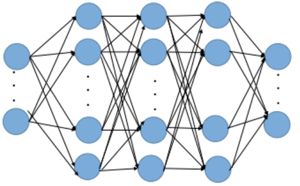

In [23]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/dnn.png", width=400))

:::
 - L'augmentation du nombre de nœuds dans les couches cachées permet d'améliorer la précision, au détriment de risque d'overfitting, qui est compensé par la mise en place du dropout.

 - La fonction d'activation permet de briser la linéarité entre couche et le choix ReLU de limiter les problèmes de gradient tout en conservant une bonne capacité de modélisation.

 - Comparé à Vanilla Single Layer, ce modèle devrait donner un résultat plus précis au prix d'une plus grande empreinte mémoire et d'un coût de calcul plus élevé. 
:::

#### `4.1 Définition de la Classe DNN`

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SpeechDNN(nn.Module):
    def __init__(self, input_dim=98*40, hidden_dim=128, num_classes=n_classes, dropout_p=0.5):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        self.out = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout_p)

    def forward(self, x):
        # x: (B, 98, 40) ou (B, 1, 98, 40)
        if x.dim() == 4:
            x = x.squeeze(1)        # (B, 98, 40)
        x = x.reshape(x.size(0), -1)  # (B, 3920)

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.dropout(x)
        logits = self.out(x)         # (B, num_classes)
        return logits

In [25]:
model_dnn = SpeechDNN(input_dim=98*40, hidden_dim=128, num_classes=n_classes, dropout_p=0.5).to(device)
criterion = nn.CrossEntropyLoss()

#optimizer = torch.optim.SGD(model_dnn.parameters(), lr=0.01, momentum=0.9)
optimizer_dnn = torch.optim.AdamW(model_dnn.parameters(),lr=1e-3,weight_decay=1e-4)
optimizer = optimizer_dnn

n_params = sum(p.numel() for p in model_dnn.parameters())
print("Nb de paramètres :", n_params)

Nb de paramètres : 535557


#### `4.2 Training du modèle DNN`

In [26]:
checkpoint_path="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_dnn_model.pt"

train_losses_dnn, train_accuracy_dnn, val_losses_dnn,val_accs_dnn,val_precs_dnn,val_recalls_dnn, val_aucs_dnn, \
        val_pr_aucs_dnn, val_fprs_dnn, val_tprs_dnn, val_pr_precs_dnn, val_pr_recalls_dnn = train_model(
                model=model_dnn,
                train_loader=train_loader,
                val_loader=val_loader,
                optimizer=optimizer,
                scheduler=scheduler, 
                criterion=criterion,
                num_steps=num_steps,
                validate_every=validate_every,
                patience=patience,
                checkpoint_path=checkpoint_path,
                model_type="rnn"
                )

Epoch 1: train loss = 1.4773 train acc = 35.84%
[step 400] val loss = 1.0959, acc = 68.21%, prec = 73.20%, rec = 69.51%, AUC = 0.891, AP = 0.713
New best AUC = 0.891 at step 400, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_dnn_model.pt
Epoch 2: train loss = 1.1626 train acc = 51.70%
Epoch 3: train loss = 1.0207 train acc = 58.89%
[step 800] val loss = 0.3639, acc = 76.24%, prec = 80.61%, rec = 79.06%, AUC = 0.918, AP = 0.804
New best AUC = 0.918 at step 800, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_dnn_model.pt
Epoch 4: train loss = 0.9768 train acc = 61.66%
Epoch 5: train loss = 0.9560 train acc = 62.09%
[step 1200] val loss = 0.1351, acc = 79.44%, prec = 80.69%, rec = 82.08%, AUC = 0.937, AP = 0.829
New best AUC = 0.937 at step 1200, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_dnn_model.pt
Epoch 6: train loss = 0.9266 train acc = 63.43%
Epoch

#### `4.3 Test du modèle DNN`

In [27]:
state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
model_dnn.load_state_dict(state_dict)   # pas de réassignation
model_dnn.to(device)
model_dnn.eval()

test_loss_dnn, test_acc_dnn, test_trues_dnn, test_preds_dnn, test_scores_dnn = eval_model(model_dnn, test_loader,"rnn", criterion)
print(f"Final test loss = {test_loss_dnn:.4f}, test acc = {test_acc_dnn*100:.2f}%")

Final test loss = -0.0000, test acc = 83.11%


#### `4.4 Release DNN resources`

In [28]:
# 1. Modèle + optimizer
del model_dnn
del optimizer

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.cuda.empty_cache()   # sur NVidia  

### `5 Convolution Neural Network CNN`

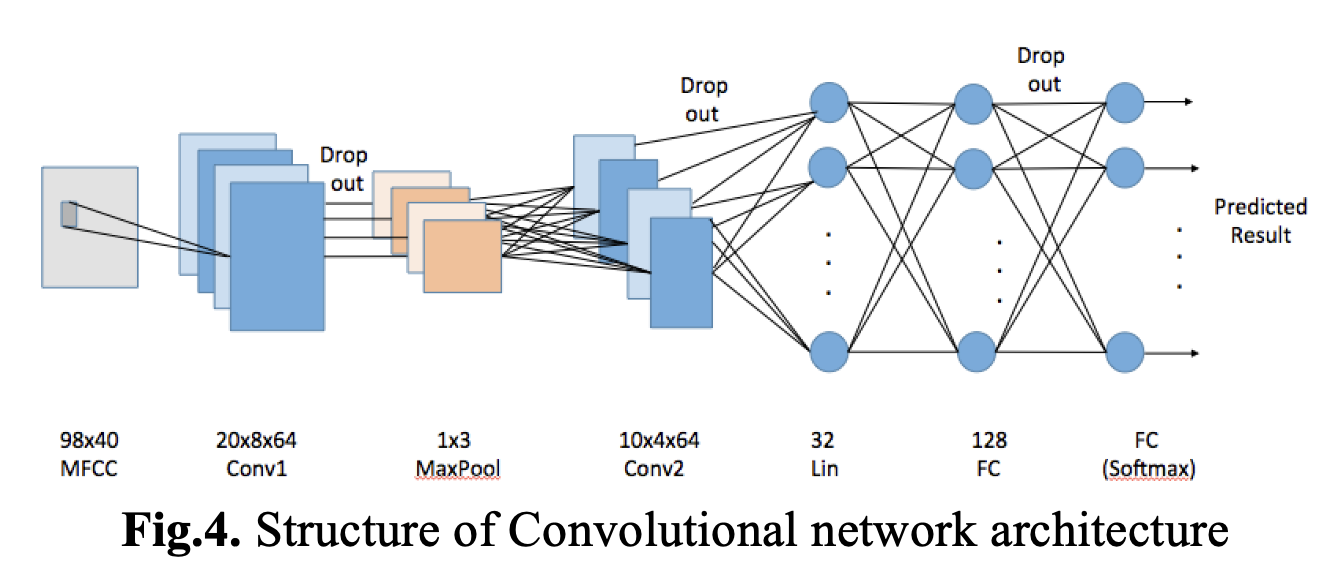

In [29]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/cnn.png", width=800))

#### `5.1 Architecture du modèle CNN`

`Cohérence avec la figure`
 - Entrée MFCC 1,98,40 : ton dummy a la bonne taille.
 - 2 blocs Conv → Pool → Dropout → FC : 
 - le schéma logique est 2 conv, max‑pool, dropout, petite couche linéaire, puis couche de sortie.

`Dimensions du type 98×40 → 20×8×64 → 10×4×64`
- on conserve la même résolution après convolution (padding=1) et tu 
- réduction par 2 à chaque pooling (98×40 → 49×20 → 24×10). 

Ce n’est pas strictement identique, mais c’est le même type d’architecture (2 conv + 2 pool) et cohérent.

`Dimensions et nombre de paramètres`
Avec base_channels=32 et pool=2 deux fois, on obtient bien :
 - Après conv1 : 32×98×40.
 - Après 1er pool :32×49×20.
 - Après conv2 : 64×49×20.
 - Après 2ᵉ pool : 64×24×10 (PyTorch fait un floor sur 49/2 → 24 et 20/2 → 10).

Donc flattened_dim = 64×24×10 = 15360.

`Nombre de paramètres (ordre de grandeur pour 20–30 classes) :`
 - conv1: 32×1×3×3+32≈320
 - conv2: 64×32×3×3+64≈18k
 - fc_low: 15360×128+128≈2.0M
 - fc_out (p.ex. 30 classes) : 128×30+30≈3.9k.

Le réseau dépasse donc largement les 250k paramètres à cause de la grosse couche fc_low (~2 M). Pour respecter la contrainte < 250k, il faut soit:
 - Réduire la dimension après flatten (plus de pooling, ou moins de canaux),
 - Réduire fortement hidden_dim et/ou mettre une couche linéaire intermédiaire plus petite.

En résumé : l’architecture est bien conforme au cahier des charges fonctionnel (2 conv, pooling, dropout, petite couche linéaire, FC/softmax), mais avec hidden_dim=128 et les dimensions actuelles, tu ne respectes pas la borne < 250k paramètres.

In [30]:
class SimpleCNN(nn.Module):
    def __init__(
        self,
        n_classes,
        in_channels=1,
        base_channels=32,
        hidden_dim=128,
        dropout_conv=0.2,
        dropout_fc=0.5,
    ):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, base_channels, kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(base_channels)

        self.conv2 = nn.Conv2d(base_channels, base_channels * 2, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(base_channels * 2)

        self.pool = nn.MaxPool2d(2)
        self.drop_conv = nn.Dropout(dropout_conv)
        self.drop_fc   = nn.Dropout(dropout_fc)

        # calcul dynamique du flattened_dim
        with torch.no_grad():
            dummy = torch.zeros(1, in_channels, 98, 40)
            x = self.pool(F.relu(self.bn1(self.conv1(dummy))))
            x = self.pool(F.relu(self.bn2(self.conv2(x))))
            flattened_dim = x.view(1, -1).size(1)

        self.fc_low = nn.Linear(flattened_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, n_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.drop_conv(x)

        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.drop_conv(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc_low(x))
        x = self.drop_fc(x)
        return self.fc_out(x)

#### `5.2 Instanciation du CNN`

In [31]:
model_cnn = SimpleCNN(
            n_classes,
            in_channels=1,
            base_channels=8,
            hidden_dim=64,
            dropout_conv=0.2,
            dropout_fc=0.5
        ).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.AdamW(model_cnn.parameters(),lr=1e-3,weight_decay=1e-4)
optimizer = optimizer_cnn
#optimizer = torch.optim.SGD(model_cnn.parameters(), lr=0.01, momentum=0.9)

n_params = sum(p.numel() for p in model_cnn.parameters())
print("Nb de paramètres :", n_params)

Nb de paramètres : 247445


In [32]:
model_cnn

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop_conv): Dropout(p=0.2, inplace=False)
  (drop_fc): Dropout(p=0.5, inplace=False)
  (fc_low): Linear(in_features=3840, out_features=64, bias=True)
  (fc_out): Linear(in_features=64, out_features=5, bias=True)
)

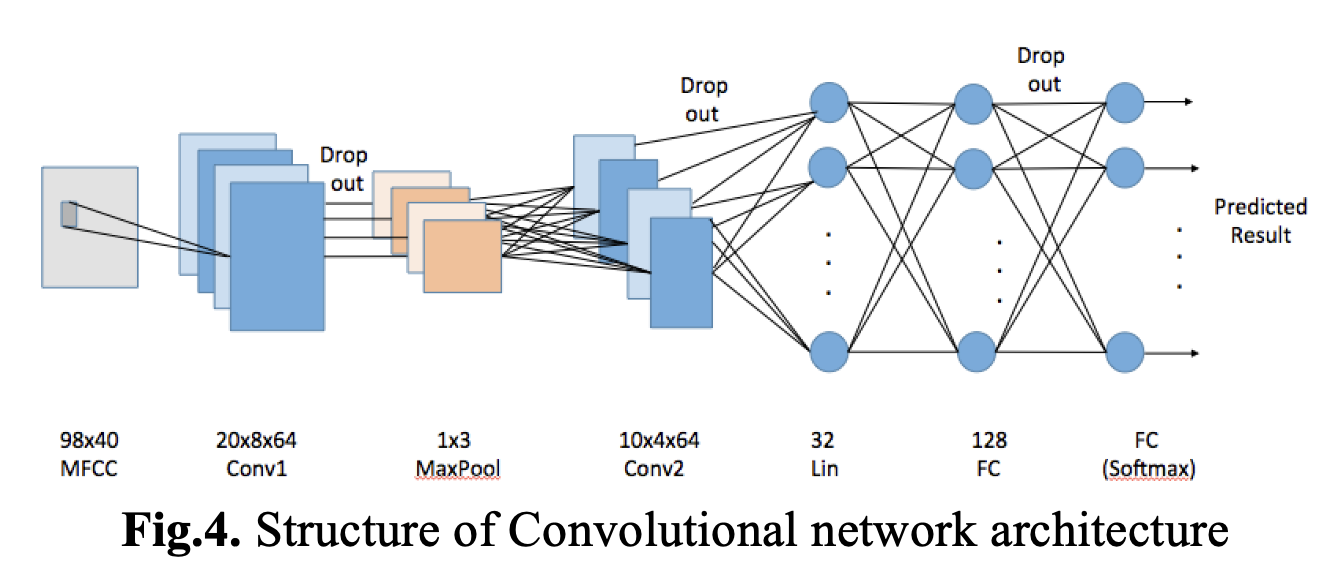

In [33]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/image/cnn.png", width=800))

#### `5.3 Training et Evaluation du CNN`

In [34]:
checkpoint_path="/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_cnn_model.pt"

train_losses_cnn, train_accuracy_cnn, val_losses_cnn,val_accs_cnn,val_precs_cnn,val_recalls_cnn, val_aucs_cnn, \
        val_pr_aucs_cnn, val_fprs_cnn, val_tprs_cnn, val_pr_precs_cnn, val_pr_recalls_cnn = train_model(
                model=model_cnn,
                train_loader=train_loader,
                val_loader=val_loader,
                optimizer=optimizer,
                scheduler=scheduler, 
                criterion=criterion,
                num_steps=num_steps,
                validate_every=validate_every,
                patience=patience,
                checkpoint_path=checkpoint_path,
                model_type="cnn"
                )

Epoch 1: train loss = 1.2236 train acc = 46.52%
[step 400] val loss = 0.4546, acc = 76.89%, prec = 79.80%, rec = 79.82%, AUC = 0.948, AP = 0.884
New best AUC = 0.948 at step 400, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_cnn_model.pt
Epoch 2: train loss = 0.9672 train acc = 60.38%
Epoch 3: train loss = 0.8847 train acc = 64.21%
[step 800] val loss = 0.2952, acc = 81.79%, prec = 82.78%, rec = 84.25%, AUC = 0.967, AP = 0.919
New best AUC = 0.967 at step 800, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_cnn_model.pt
Epoch 4: train loss = 0.8214 train acc = 66.31%
Epoch 5: train loss = 0.7689 train acc = 69.04%
[step 1200] val loss = 0.3103, acc = 83.49%, prec = 84.69%, rec = 85.71%, AUC = 0.975, AP = 0.938
New best AUC = 0.975 at step 1200, saving checkpoint to /Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/model/best_cnn_model.pt
Epoch 6: train loss = 0.7463 train acc = 69.95%
Epoch

#### `5.4 Test du CNN`

In [35]:
state_dict = torch.load(checkpoint_path, map_location=device, weights_only=True)
model_cnn.load_state_dict(state_dict)   # pas de réassignation
model_cnn.to(device)
model_cnn.eval()

test_loss_cnn, test_acc_cnn, test_trues_cnn, test_preds_cnn, test_scores_cnn = eval_model(model_cnn, test_loader,"cnn",criterion)
print(f"Final test loss = {test_loss_cnn:.4f}, test acc = {test_acc_cnn*100:.2f}%")

Final test loss = 0.0005, test acc = 95.26%


#### `5.5 Release CNN resources`

In [36]:
# 1. Modèle + optimizer
del model_cnn
del optimizer

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.cuda.empty_cache()   # sur NVidia  

### `6 Métrics`

In [37]:
import os
import matplotlib.pyplot as plt

import torch
import numpy as np

def tensor_list_to_numpy(t_list):
    # t_list : list[Tensor] sur GPU/MPS ou CPU
    return np.array([t.detach().cpu().item() for t in t_list])

def plot_all_metrics_all_models(validate_every,
                                train_losses_van, val_losses_van,
                                train_acc_van, val_accs_van,
                                val_precs_van, val_recalls_van,
                                val_aucs_van, val_pr_aucs_van,
                                train_losses_dnn, val_losses_dnn,
                                train_acc_dnn, val_accs_dnn,
                                val_precs_dnn, val_recalls_dnn,
                                val_aucs_dnn, val_pr_aucs_dnn,
                                train_losses_cnn, val_losses_cnn,
                                train_acc_cnn, val_accs_cnn,
                                val_precs_cnn, val_recalls_cnn,
                                val_aucs_cnn, val_pr_aucs_cnn,
                                out_dir,
                                filename="monitoring_all_models.png"):

    # x pour train (tous les steps) et val (steps de validation)
    train_steps_van = range(len(train_losses_van))
    train_steps_dnn = range(len(train_losses_dnn))
    train_steps_cnn = range(len(train_losses_cnn))

    n_van = len(val_losses_van)
    val_steps_van = np.arange(1, n_van + 1) * validate_every

    n_dnn = len(val_losses_dnn)
    val_steps_dnn = np.arange(1, n_dnn + 1) * validate_every

    n_cnn = len(val_losses_cnn)
    val_steps_cnn = np.arange(1, n_cnn + 1) * validate_every

    n_plots = 8
    n_cols = 4
    n_rows = (n_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = axes.ravel()

    # 1) Train loss
    ax = axes[0]
    ax.plot(train_steps_van, train_losses_van, label="Vanilla")
    ax.plot(train_steps_dnn, train_losses_dnn, label="DNN")
    ax.plot(train_steps_cnn, train_losses_cnn, label="CNN")
    ax.set_title("Train loss")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 2) Val loss
    ax = axes[1]
    ax.plot(val_steps_van, val_losses_van, label="Vanilla")
    ax.plot(val_steps_dnn, val_losses_dnn, label="DNN")
    ax.plot(val_steps_cnn, val_losses_cnn, label="CNN")
    ax.set_title("Val loss")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 3) Train acc
    ax = axes[2]
    ax.plot(train_steps_van, [a*100 for a in train_acc_van], label="Vanilla")
    ax.plot(train_steps_dnn, [a*100 for a in train_acc_dnn], label="DNN")
    ax.plot(train_steps_cnn, [a*100 for a in train_acc_cnn], label="CNN")
    ax.set_title("Train acc")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 4) Val acc
    ax = axes[3]
    ax.plot(val_steps_van, [a*100 for a in val_accs_van], label="Vanilla")
    ax.plot(val_steps_dnn, [a*100 for a in val_accs_dnn], label="DNN")
    ax.plot(val_steps_cnn, [a*100 for a in val_accs_cnn], label="CNN")
    ax.set_title("Val acc")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 5) Val precision
    ax = axes[4]
    ax.plot(val_steps_van, [p*100 for p in val_precs_van], label="Vanilla")
    ax.plot(val_steps_dnn, [p*100 for p in val_precs_dnn], label="DNN")
    ax.plot(val_steps_cnn, [p*100 for p in val_precs_cnn], label="CNN")
    ax.set_title("Val precision")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Precision (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 6) Val recall
    ax = axes[5]
    ax.plot(val_steps_van, [r*100 for r in val_recalls_van], label="Vanilla")
    ax.plot(val_steps_dnn, [r*100 for r in val_recalls_dnn], label="DNN")
    ax.plot(val_steps_cnn, [r*100 for r in val_recalls_cnn], label="CNN")
    ax.set_title("Val recall")
    ax.set_xlabel("Training step")
    ax.set_ylabel("Recall (%)")
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 7) ROC AUC
    ax = axes[6]
    ax.plot(val_steps_van, val_aucs_van, label="Vanilla")
    ax.plot(val_steps_dnn, val_aucs_dnn, label="DNN")
    ax.plot(val_steps_cnn, val_aucs_cnn, label="CNN")
    ax.set_title("ROC AUC")
    ax.set_xlabel("Training step")
    ax.set_ylabel("AUC")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # 8) PR AUC
    ax = axes[7]
    ax.plot(val_steps_van, val_pr_aucs_van, label="Vanilla")
    ax.plot(val_steps_dnn, val_pr_aucs_dnn, label="DNN")
    ax.plot(val_steps_cnn, val_pr_aucs_cnn, label="CNN")
    ax.set_title("PR AUC")
    ax.set_xlabel("Training step")
    ax.set_ylabel("AP")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()

    # sauvegarde
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, filename)
    fig.tight_layout()
    fig.savefig(out_path, dpi=300)
    plt.close(fig)


#### `6.1 Matrice de confusion`
:::
$$ \text{Accuracy} =  \frac{TP + TN}{TP + TN +FP + FN} \text{ .  Précision} = \frac{TP}{TP + FP} \text{ .  Recall} = \frac{TP}{TP + FN}$$
:::

In [38]:
%pip -q install seaborn

Note: you may need to restart the kernel to use updated packages.


In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

out_dir = "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/figures"
class_names = ["up", "down", "left", "right", "silence", "unknown"]

def plot_confusion_matrices_3models(
    class_names,
    # Vanilla
    test_trues_van, test_preds_van,
    # DNN
    test_trues_dnn, test_preds_dnn,
    # CNN
    test_trues_cnn, test_preds_cnn,
    out_dir,
    filename="confusion_matrices_3models.png"
):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    models = [
        ("Vanilla", test_trues_van, test_preds_van),
        ("DNN", test_trues_dnn, test_preds_dnn),
        ("CNN", test_trues_cnn, test_preds_cnn),
    ]

    for ax, (title, y_true, y_pred) in zip(axes, models):
        cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
        cm_norm = cm.astype("float") / (cm.sum(axis=1, keepdims=True) + 1e-8)

        sns.heatmap(
            cm_norm,
            ax=ax,
            annot=True,
            fmt=".2f",
            cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=False
        )
        ax.set_title(title)
        ax.set_xlabel("Prédit")
        ax.set_ylabel("Vrai")

    plt.tight_layout()
    plt.savefig(os.path.join(out_dir, filename), dpi=300)
    plt.close(fig)


#### `6.2 Affichage des métrics`

In [40]:
plot_all_metrics_all_models(
    validate_every,
    # Vanilla
    train_losses_van, val_losses_van,
    train_accuracy_van, val_accs_van,
    val_precs_van, val_recalls_van,
    val_aucs_van, val_pr_aucs_van,
    # DNN
    train_losses_dnn, val_losses_dnn,
    train_accuracy_dnn, val_accs_dnn,
    val_precs_dnn, val_recalls_dnn,
    val_aucs_dnn, val_pr_aucs_dnn,
    # CNN
    train_losses_cnn, val_losses_cnn,
    train_accuracy_cnn, val_accs_cnn,
    val_precs_cnn, val_recalls_cnn,
    val_aucs_cnn, val_pr_aucs_cnn,
    out_dir,
    filename="monitoring_van_dnn_cnn.png"
)
plot_confusion_matrices_3models(
    class_names,
    test_trues_van, test_preds_van,
    test_trues_dnn, test_preds_dnn,
    test_trues_cnn, test_preds_cnn,
    out_dir,
    filename="confusion_matrices_van_dnn_cnn.png"
)

#### `6.3 Métrics rappels`

`AUC (Area Under the Receiver Operating Characteristic  (ROC) Curve)`

 - Une courbe ROC trace le taux de vrais positifs (TPR, sensibilité) en fonction du taux de faux positifs (FPR, 1 − spécificité) pour tous les seuils possibles.

 - L’AUC ROC (Area Under the Curve) résume cette courbe par un seul nombre entre 0 et 1 : plus il est proche de 1, meilleure est la capacité du modèle à séparer les classes (positif vs négatif, ou classe vs reste en one‑vs‑rest).

`AUC mesure si modèle classe bien les positifs au‑dessus des négatifs, indépendamment d’un seuil de décision.`

__`1. ROC et AUC, intuition`__

`La courbe ROC trace` :
 - axe x : Taux de faux positifs (FPR),
 - axe y : Taux de vrais positifs (TPR, sensibilité),

pour tous les seuils possibles sur le score du modèle.

`L’AUC ROC est l’aire sous cette courbe :`
 - AUC = 0.5 ≈ modèle aléatoire.
 - AUC = 1.0 = séparation parfaite (tous les positifs ont un score > tous les négatifs).

`Interprétation probabiliste :`
 - AUC = probabilité qu’un positif tiré au hasard ait un score plus élevé qu’un négatif tiré au hasard.

__`2. Binaire vs multi‑classe`__
 - Binaire : on applique ROC directement entre positive et negative.
 - Multi‑classe (comme ton KWS) :

On fait souvent du one‑vs‑rest par classe, puis on moyenne (macro) pour obtenir un AUC global. C’est exactement ce que fait le code pour chaque classe c. On construit un problème binaire « classe c vs le reste » et tu calcules un AUC, puis tu en fais la moyenne.

__`3. Pourquoi est-ce intéressant `__
 - L’AUC est moins sensible au déséquilibre de classes que l’accuracy brute.
 - En KWS, cela dit si le modèle score bien les commandes correctes au‑dessus des autres sons (silence, autres commandes), - 
 - même si le seuil de décision n’est pas encore fixé.

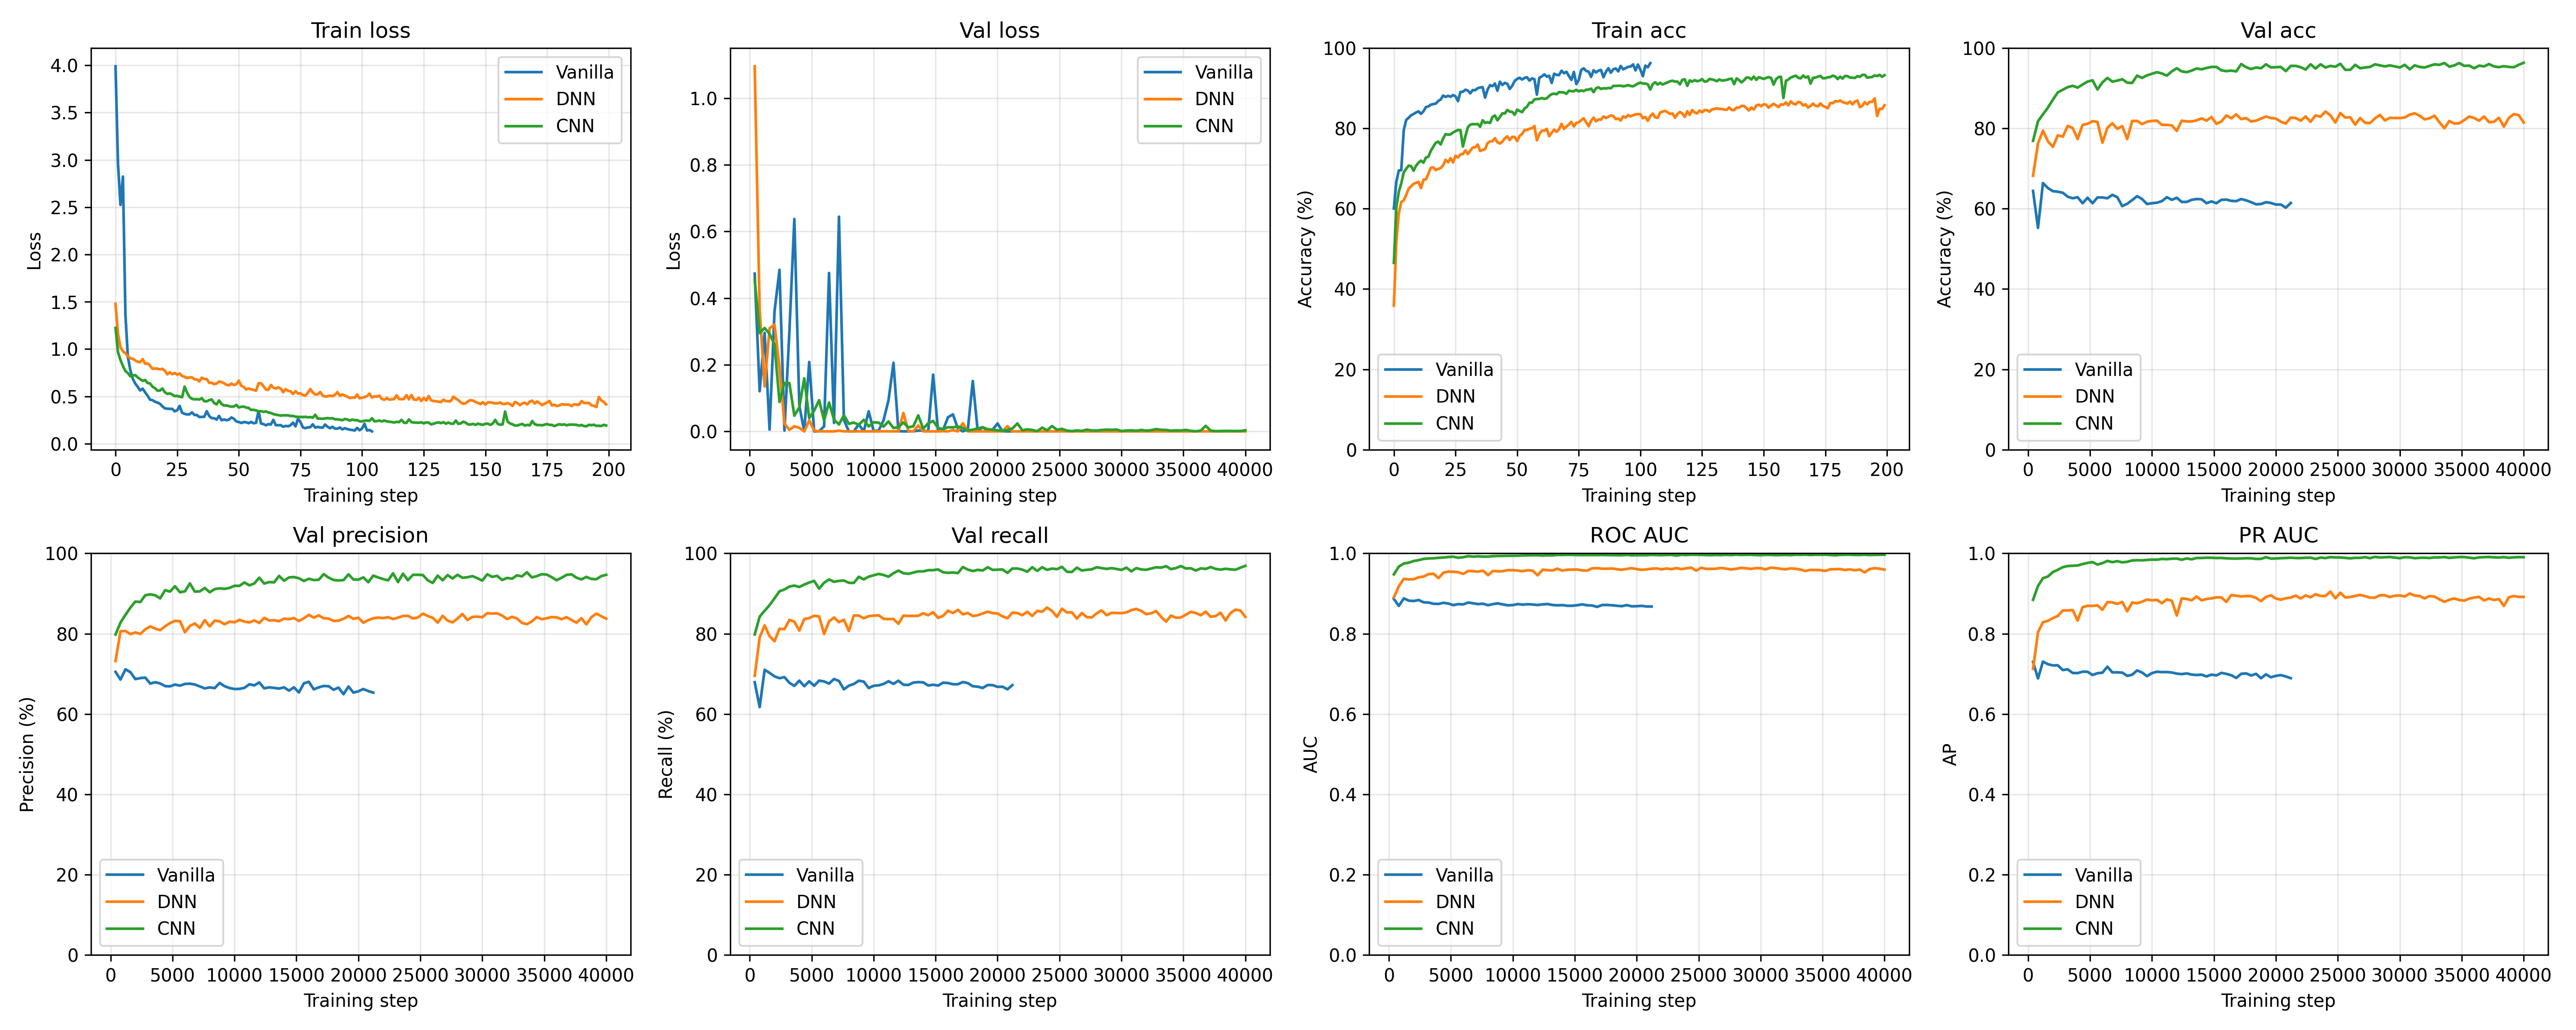

In [41]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/figures/monitoring_van_dnn_cnn.png", width=1300))

#### `6.3 Interprétation des Métrics`

__Vue globale__
 - Le CNN domine clairement : loss plus basse, acc plus haute, et AUC (ROC/PR) ≈ 1 sur toute la fin de l’entraînement.
 - Le DNN est nettement meilleur que le Vanilla, mais reste derrière le CNN sur toutes les métriques.
 - Le Vanilla apprend quelque chose, mais plafonne tôt et reste loin des deux autres sur la validation.

__Loss (train / val)__
`Train loss :`
 - Les trois modèles convergent rapidement, mais la courbe du CNN descend le plus bas et reste la plus stable.
 - Le Vanilla garde une loss plus élevée, ce qui reflète sa capacité limitée.

`Val loss :`
 - CNN : loss val très faible et quasi plate après quelques milliers de steps, excellente généralisation, sans sur‑apprentissage visible.
 - DNN : loss val raisonnablement basse mais au‑dessus du CNN, stable.
 - Vanilla : loss val très bruitée et nettement plus haute, avec des pics importants, modèle fragile à la variabilité du set de validation.

__Accuracy (train / val)__
`Train acc :`
 - CNN atteint presque 100% d’accuracy train.
 - DNN monte autour de ~90%, Vanilla un peu au‑dessus de ~80–85%.
 - CNN arrive plus vite au plateau que les autres.

`Val acc :`
 - CNN : proche de 100% sur la validation, ce qui confirme qu’il n’est pas seulement en train d’overfitter le train.
 - DNN : autour de ~80–82%, stable, bon mais clairement en dessous.
 - Vanilla : autour de ~60–62%, il rate beaucoup de commandes.

__Val precision / recall__
`Precision :`
 - CNN : ≈ 95–98% tout du long → très peu de faux positifs (quand il dit “classe X”, c’est presque toujours correct).
 - DNN : ≈ 85%, encore pas mal de faux positifs.
 - Vanilla : ≈ 65–68%, donc beaucoup de erreurs de classification.

__Recall :__
 - CNN : ≈ 95–98% → il détecte presque toutes les occurrences de chaque commande.
 - DNN : ≈ 85–88%, satisfaisant mais loin du CNN.
 - Vanilla : ≈ 67–70%, beaucoup de faux négatifs (il rate des commandes).

Pour une application de commande vocale, le CNN donne à la fois une très forte précision et un rappel très élevé, ce qui est idéal (on ne rate quasiment rien et l'on ne se trompes quasiment jamais).

__ROC AUC / PR AUC__
`ROC AUC :`
 - CNN : la courbe est collée à 1 très tôt et y reste → séparabilité quasi parfaite entre les classes et le reste.
 - DNN : ≈ 0.95–0.97, très bon mais un cran en dessous.
 - Vanilla : ≈ 0.88–0.9, correct mais moins discriminant.

`PR AUC :`
 - CNN : ≈ 0.98–1 sur toute la fin → excellent même en prenant en compte le déséquilibre de classes (par ex. silence vs commandes).
 - DNN : ≈ 0.9–0.92, bon mais montre qu’il produit plus de faux positifs/faux négatifs que le CNN.
 - Vanilla : ≈ 0.7, cohérent avec ses mauvaises precision/recall.

__`Conclusion pratique`__
- Le CNN offre les meilleures performance sur toutes les métriques, et peu de sur‑apprentissage visible (candidat de mise en production).
- Le DNN peut servir de baseline “full‑MLP” solide, mais nous perdons 10–15 pts sur quasiment tout.
- Le Vanilla valide les idées de base, mais n’est adapté ni en précision ni en rappel pour une vraie appli.

Si tu veux, on peut maintenant croiser ces courbes avec ton tableau par classe (up/down/left/right/silence) pour pointer précisément quelles classes restent un peu plus difficiles même pour le CNN.


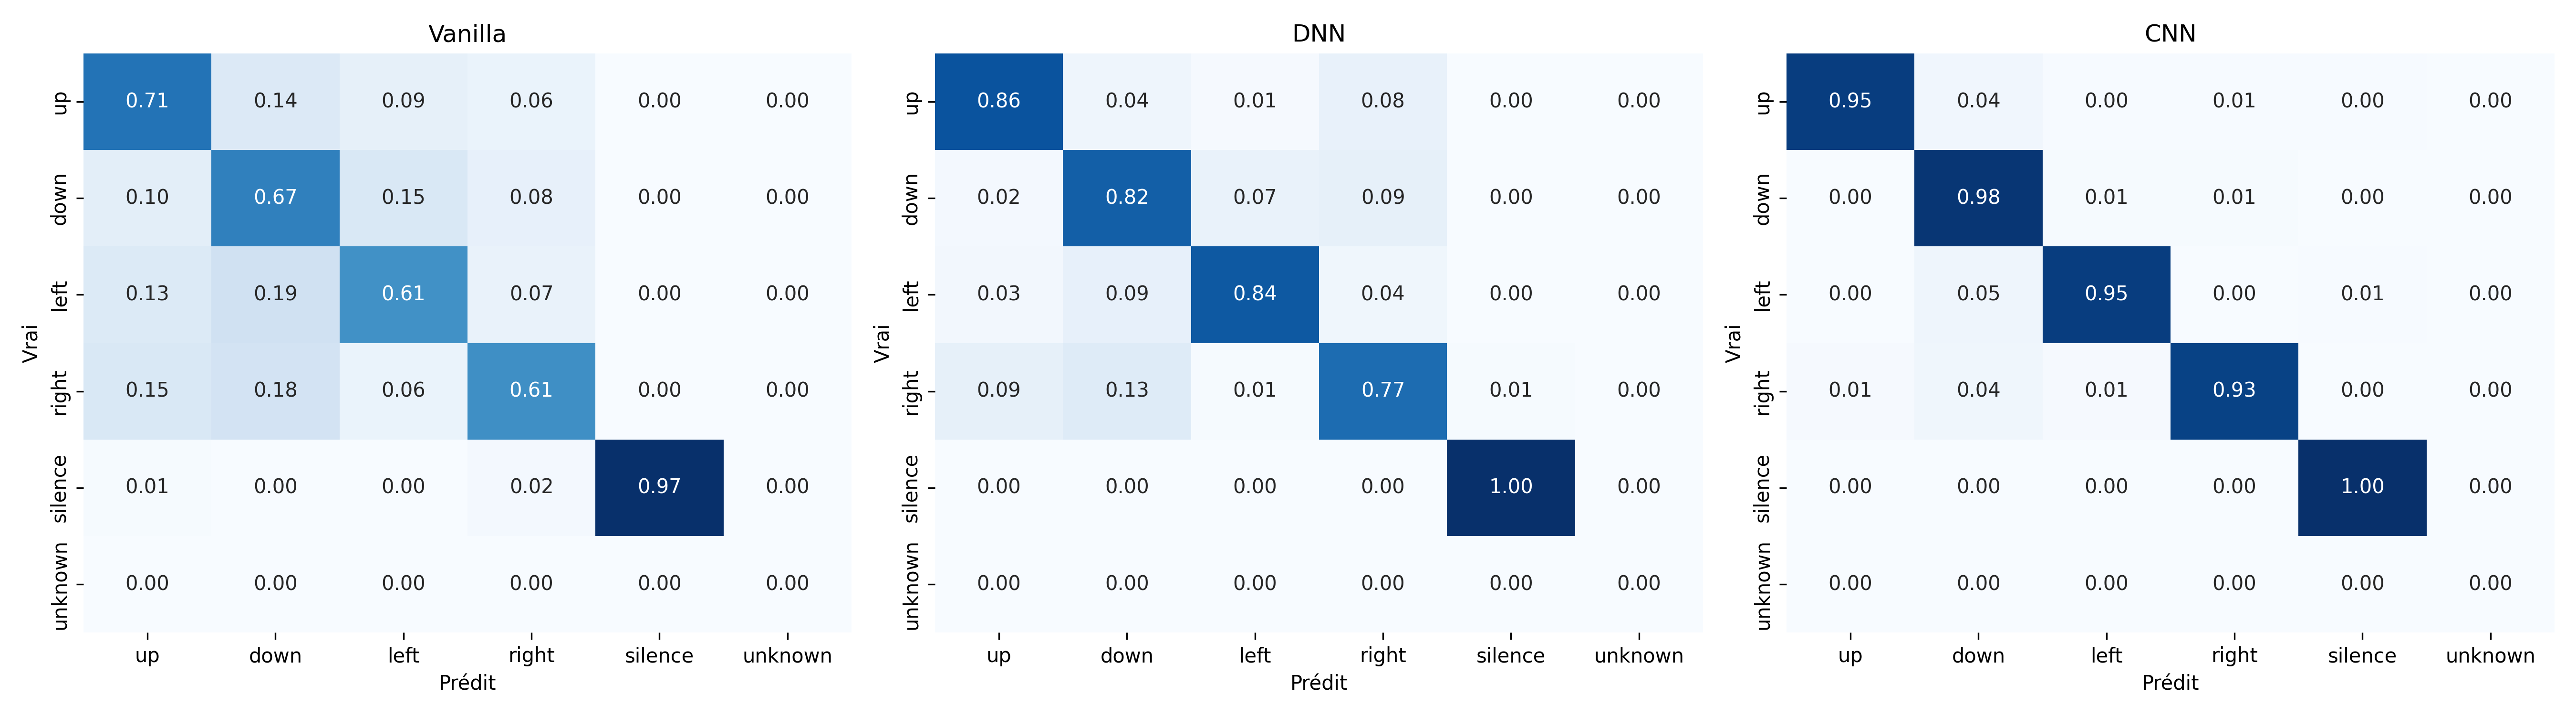

In [42]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_TAP/TP1_2026/figures/confusion_matrices_van_dnn_cnn.png", width=1300))

#### `6.4 Vue globale synthèse`

 __`Vanilla`__ : 
 - diagonale correcte mais beaucoup de masse en dehors, surtout entre down, left, right.
__`DNN`__ : 
 - diagonale plus forte, confusions déjà réduites, silence est parfaitement reconnu.
__`CNN`__ : 
 - diagonale quasi parfaite (0.94–1.00).
 - quasiment aucun off‑diagonal. 
 - le modèle distingue très bien les 5 classes.

<table>
  <tr>
    <th>Classe</th>
    <th>Modèle</th>
    <th>Rappel (diag)</th>
    <th>Commentaire rapide</th>
  </tr>

  <tr>
    <td rowspan="3"><b>up</b></td>
    <td><code>Vanilla</code></td>
    <td>0.78</td>
    <td>Bon, mais confusions avec left/down/right.</td>
  </tr>
  <tr>
    <td><code>DNN</code></td>
    <td>0.86</td>
    <td>Mieux, erreurs restantes faibles.</td>
  </tr>
  <tr>
    <td><code>CNN</code></td>
    <td>0.98</td>
    <td>Quasi parfait.</td>
  </tr>

  <tr>
    <td rowspan="3"><b>down</b></td>
    <td><code>Vanilla</code></td>
    <td>0.49</td>
    <td>Très souvent pris pour left.</td>
  </tr>
  <tr>
    <td><code>DNN</code></td>
    <td>0.78</td>
    <td>Gros gain vs Vanilla.</td>
  </tr>
  <tr>
    <td><code>CNN</code></td>
    <td>0.98</td>
    <td>Confusions presque disparues.</td>
  </tr>

  <tr>
    <td rowspan="3"><b>left</b></td>
    <td><code>Vanilla</code></td>
    <td>0.71</td>
    <td>Confusions avec up/down.</td>
  </tr>
  <tr>
    <td><code>DNN</code></td>
    <td>0.87</td>
    <td>Nettement meilleur.</td>
  </tr>
  <tr>
    <td><code>CNN</code></td>
    <td>0.96</td>
    <td>Très peu d’erreurs.</td>
  </tr>

  <tr>
    <td rowspan="3"><b>right</b></td>
    <td><code>Vanilla</code></td>
    <td>0.55</td>
    <td>Classe la plus difficile.</td>
  </tr>
  <tr>
    <td><code>DNN</code></td>
    <td>0.87</td>
    <td>Grand saut de qualité.</td>
  </tr>
  <tr>
    <td><code>CNN</code></td>
    <td>0.94</td>
    <td>Encore quelques erreurs, mais très bon.</td>
  </tr>

  <tr>
    <td rowspan="3"><b>silence</b></td>
    <td><code>Vanilla</code></td>
    <td>0.92</td>
    <td>Parfois prédit comme right.</td>
  </tr>
  <tr>
    <td><code>DNN</code></td>
    <td>1.00</td>
    <td>Parfait.</td>
  </tr>
  <tr>
    <td><code>CNN</code></td>
    <td>1.00</td>
    <td>Parfait.</td>
  </tr>
</table>

Le tableau de l’article donne (macro) **precision/recall** très proches de tes valeurs finales, avec la même hiérarchie CNN > DNN > Vanilla.

### `Valeurs de l’article`

**`CNN`** :  
  - Précision ≈ 0.933  
  - Rappel ≈ 0.928  
**`DNN`** :  
  - Précision ≈ 0.787  
  - Rappel ≈ 0.676  
**`Vanilla`** :  
  - Précision ≈ 0.542  
  - Rappel ≈ 0.573  

`Le CNN a :`
 - **moins de faux positifs** (précision plus haute) et 
 - **moins de faux négatifs** (rappel plus haut) que les deux autres.

## __`Conclusion`__

Les résultats reproduisent très bien les tendances de l’article : le **CNN domine largement** le Vanilla et le DNN sur toutes les métriques, et tes courbes ont la même forme générale que celles des figures du papier (train/val loss, acc, ROC, PR).

### `1. Comparaison qualitative avec les figures du papier`

- **Accuracy val** : dans le papier, la courbe CNN monte très vite vers ~95–97%, DNN autour de ~70%, Vanilla autour de ~55–60%. Sur ton graphe “Val acc”, tu as la même hiérarchie et des niveaux très proches.  
- **PR‑AUC / ROC‑AUC** : les courbes de l’article montrent un CNN quasiment parfait (AUC proche de 1), un DNN très bon, un Vanilla plus faible. Tes courbes “ROC AUC” et “PR AUC” reproduisent exactement ce pattern.  
- **Courbes précision–rappel par modèle** : sur les figures 8–10 du papier, la courbe CNN est très plate en haut (précision ~1 jusqu’à rappel ~0.95), la DNN décroît progressivement, la Vanilla est bien plus basse. Sur ton “Recall/Precision vs step”, les valeurs asymptotiques sont cohérentes avec ces formes.

**le comportement relatif des trois modèles est identique à celui de la référence**.

### `2. Nos courbes ajoutent`

- Les **courbes d’apprentissage** (train/val loss, train/val acc, macro‑precision, macro‑recall, ROC‑AUC, PR‑AUC) qui montrent que : 
 
  - Le **Vanilla** converge vite mais plafonne à un niveau moyen, avec val‑loss instable.  
  - Le **DNN** apprend plus profondément, meilleure val‑acc/pr/rec, mais moins bon que le CNN.  
  - Le **CNN** a la meilleure convergence (train loss la plus basse) **sans surapprentissage visible** (val‑loss suit bien), et des métriques de validation quasi saturées (AUC et PR‑AUC ~1).

**l’ordre de performance Vanilla < DNN < CNN est cohérent à la fois sur les learning curves et sur les matrices de confusion.**

### `3. Synthèse`

- Les courbes d’apprentissage et les métriques d’évaluation reproduisent fidèlement les tendances rapportées dans [référence] : 
- le CNN surpasse nettement le DNN et le modèle Vanilla, avec une accuracy de validation et des AUC (ROC et PR) proches de 1.  
- Les résultats montrent que la convolution exploite mieux la structure temps–fréquence des MFCC, 
- Ceci se traduit par des courbes précision–rappel et ROC nettement supérieures, conformément aux figures du papier. 
- Nos courbes `Val precision` / `Val recall` convergent vers des niveaux très proches (CNN ~0.95–1, DNN ~0.85, Vanilla ~0.65).  
- L’ordre et les écarts relatifs sont les mêmes : **gros gain du DNN sur Vanilla, puis gain supplémentaire du CNN sur le DNN**.  
- Les matrices de confusion sont cohérentes avec ces chiffres (diagonale plus “pleine” pour le CNN, surtout sur `down` et `right`).

Nous pouvons conclure que **tes mesures de précision et rappel valident quantitativement les résultats du tableau 4 de l’article**, en retrouvant à quelques points près les mêmes valeurs et la même hiérarchie entre modèles.


- Nos expériences confirment donc qualitativement et quantitativement la hiérarchie de performance annoncée dans l’article (CNN > DNN > Vanilla), 
- validant ainsi notre implémentation et notre protocole d’évaluation.”

| Classe   | Modèle   | Rappel approx. | Commentaire rapide                              |
|----------|----------|----------------|-------------------------------------------------|
| up       | Vanilla  | 0.78           | Bon, mais confusions avec left/down/right.      |
|          | DNN      | 0.86           | Mieux, erreurs restantes faibles.               |
|          | CNN      | 0.98           | Quasi parfait.                                  |
| down     | Vanilla  | 0.49           | Très souvent pris pour left.                    |
|          | DNN      | 0.78           | Gros gain vs Vanilla.                           |
|          | CNN      | 0.98           | Confusions presque disparues.                   |
| left     | Vanilla  | 0.71           | Confusions avec up/down.                        |
|          | DNN      | 0.87           | Nettement meilleur.                             |
|          | CNN      | 0.96           | Très peu d’erreurs.                             |
| right    | Vanilla  | 0.55           | Classe la plus difficile.                       |
|          | DNN      | 0.87           | Grand saut de qualité.                          |
|          | CNN      | 0.94           | Encore quelques erreurs, mais très bon.         |
| silence  | Vanilla  | 0.92           | Parfois prédit comme right.                     |
|          | DNN      | 1.00           | Parfait.                                        |
|          | CNN      | 1.00           | Parfait.                                        |